In [1]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.colors as mcolors
#
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit

In [2]:
path = {'coords' : '/ocean/vvalenzuela/MOAD/grid/coordinates_seagrid_SalishSea201702.nc',
'mask' : '/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc',
'bathy' : '/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc'
}
#
coords = xr.open_dataset(path['coords'], decode_times=False)
mask = xr.open_dataset(path['mask'])
bathy = xr.open_dataset(path['bathy'])

In [3]:
def get_binned_timeseries(filename, polygon_coords, 
                          z_var='z', lon_var='lon', lat_var='lat', status_var='status', 
                          target_status=None, step=10):
    
    poly_path = Path(polygon_coords)
    timeseries_dict = {}
    
    with xr.open_dataset(filename) as data:
        z_vals = data[z_var].values
        lon_vals = data[lon_var].values
        lat_vals = data[lat_var].values
        
        # Get the number of time steps (obs dimension)
        # OceanParcels shape is usually (trajectory, obs)
        n_obs = z_vals.shape[1] 
        
        # --- UPFRONT STATUS FILTERING ---
        if target_status is not None:
            status_vals = data[status_var].values
            if isinstance(target_status, (list, tuple, np.ndarray)):
                status_mask = np.isin(status_vals, target_status)
            else:
                status_mask = status_vals == target_status
        else:
            status_mask = np.ones_like(z_vals, dtype=bool)
        # --------------------------------------
        
        if not np.any(status_mask):
            return pd.DataFrame()
            
        min_depth = np.nanmin(z_vals[status_mask])
        max_depth = np.nanmax(z_vals[status_mask])
        current_z = np.floor(min_depth / step) * step
        
        while current_z < max_depth:
            next_z = current_z + step
            bin_label = f"{int(current_z)}-{int(next_z)}"
            
            # 1. Create a mask for just this depth bin AND the correct status
            depth_mask = (z_vals >= current_z) & (z_vals < next_z)
            valid_mask = status_mask & depth_mask
            
            # Array to hold the counts for each time step
            counts_per_time = np.zeros(n_obs, dtype=int)
            
            if np.any(valid_mask):
                # 2. Extract valid coords and check if inside polygon
                valid_lon = lon_vals[valid_mask]
                valid_lat = lat_vals[valid_mask]
                points = np.column_stack((valid_lon, valid_lat))
                inside_poly = poly_path.contains_points(points)
                
                if np.any(inside_poly):
                    # 3. Get the 'obs' (time) indices of the points that matched
                    # np.where(valid_mask)[1] extracts the column (obs) index
                    valid_obs_idx = np.where(valid_mask)[1]
                    inside_obs_idx = valid_obs_idx[inside_poly]
                    
                    # 4. Tally the occurrences per time step instantly
                    counts_per_time = np.bincount(inside_obs_idx, minlength=n_obs)
            
            timeseries_dict[bin_label] = counts_per_time
            current_z = next_z
            
    # Return as a DataFrame (Rows = time steps, Columns = depth bins)
    return pd.DataFrame(timeseries_dict)

In [4]:
from Regions_functions_V2 import polygon_S1, polygon_lon_lat_S1

In [5]:
filename_y1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_1.nc'
filename_y2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_2.nc'
filename_y3 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_3.nc'
filename_y4 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_4.nc'
filename_y5 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_5.nc'
filename_y6 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_6.nc'
filename_y7 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_7.nc'
filename_y8 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_8.nc'
filename_y9 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_9.nc'

In [41]:
import pandas as pd

# List of all your filenames in chronological order
filenames = [
    filename_y1, filename_y2, filename_y3, 
    filename_y4, filename_y5, filename_y6, 
    filename_y7, filename_y8, filename_y9
]

accumulated_profiles = []
running_total = None

for i, filename in enumerate(filenames):
    # 1. Get the raw data
    current_year_df = get_binned_timeseries(filename, polygon_lon_lat_S1, target_status=2)
    
    # 2. Fix the time step discrepancy (3-hour vs 6-hour)
    # If the dataframe has 2920 rows, it's 3-hourly. 
    # Using .iloc[::2] selects every 2nd row, cutting it down to exactly 1460 rows.
    if len(current_year_df) == 2920:
        current_year_df = current_year_df.iloc[::2]
        
    # 3. Force alignment
    # Resetting the index ensures Pandas ignores the actual dates/years 
    # and just adds the data strictly based on the row number (0 to 1459).
    current_year_df = current_year_df.reset_index(drop=True)
    
    # Optional Safety Check: Ensure the data is exactly 1460 rows before adding
    if len(current_year_df) != 1460:
        print(f"Warning: Year {i+1} has {len(current_year_df)} rows instead of 1460. Alignment might fail.")
    
    # 4. Accumulate the continuous release
    if running_total is None:
        running_total = current_year_df.copy()
    else:
        # Add the current year's profile on top of the accumulated previous years
        running_total = running_total.add(current_year_df, fill_value=0)
    
    # 5. Save the accumulated profile for this specific point in time
    accumulated_profiles.append(running_total.copy())
    
    print(f"Processed and accumulated Year {i + 1}")

# --- Result Outputs ---
# You can now access any specific year's accumulation via the list index.
# For example, accumulated_profiles[2] gives you the physical state at Year 3 (Y1 + Y2 + Y3)

Processed and accumulated Year 1
Processed and accumulated Year 2
Processed and accumulated Year 3
Processed and accumulated Year 4
Processed and accumulated Year 5
Processed and accumulated Year 6
Processed and accumulated Year 7
Processed and accumulated Year 8
Processed and accumulated Year 9


In [56]:
accumulated_profiles_P = []
running_total_P = None

for i, filename in enumerate(filenames):
    # 1. Get the raw data
    current_year_df_P = get_binned_timeseries(filename, polygon_lon_lat_S1, target_status=[1,3])
    
    # 2. Fix the time step discrepancy (3-hour vs 6-hour)
    # If the dataframe has 2920 rows, it's 3-hourly. 
    # Using .iloc[::2] selects every 2nd row, cutting it down to exactly 1460 rows.
    if len(current_year_df_P) == 2920:
        current_year_df_P = current_year_df_P.iloc[::2]
        
    # 3. Force alignment
    # Resetting the index ensures Pandas ignores the actual dates/years 
    # and just adds the data strictly based on the row number (0 to 1459).
    current_year_df_P = current_year_df_P.reset_index(drop=True)
    
    # Optional Safety Check: Ensure the data is exactly 1460 rows before adding
    if len(current_year_df_P) != 1460:
        print(f"Warning: Year {i+1} has {len(current_year_df_P)} rows instead of 1460. Alignment might fail.")
    
    # 4. Accumulate the continuous release
    if running_total_P is None:
        running_total_P = current_year_df_P.copy()
    else:
        # Add the current year's profile on top of the accumulated previous years
        running_total_P = running_total_P.add(current_year_df_P, fill_value=0)
    
    # 5. Save the accumulated profile for this specific point in time
    accumulated_profiles_P.append(running_total_P.copy())
    
    print(f"Processed and accumulated Year {i + 1}")

# --- Result Outputs ---
# You can now access any specific year's accumulation via the list index.
# For example, accumulated_profiles[2] gives you the physical state at Year 3 (Y1 + Y2 + Y3)

Processed and accumulated Year 1
Processed and accumulated Year 2
Processed and accumulated Year 3
Processed and accumulated Year 4
Processed and accumulated Year 5
Processed and accumulated Year 6
Processed and accumulated Year 7
Processed and accumulated Year 8
Processed and accumulated Year 9


In [28]:
time_6h = pd.date_range(start='2007-01-01', periods=1460*9, freq='6h')

In [51]:
y_midpoints = np.array([np.mean([float(val) for val in bin_str.split('-')]) for bin_str in accumulated_profiles[0].columns])

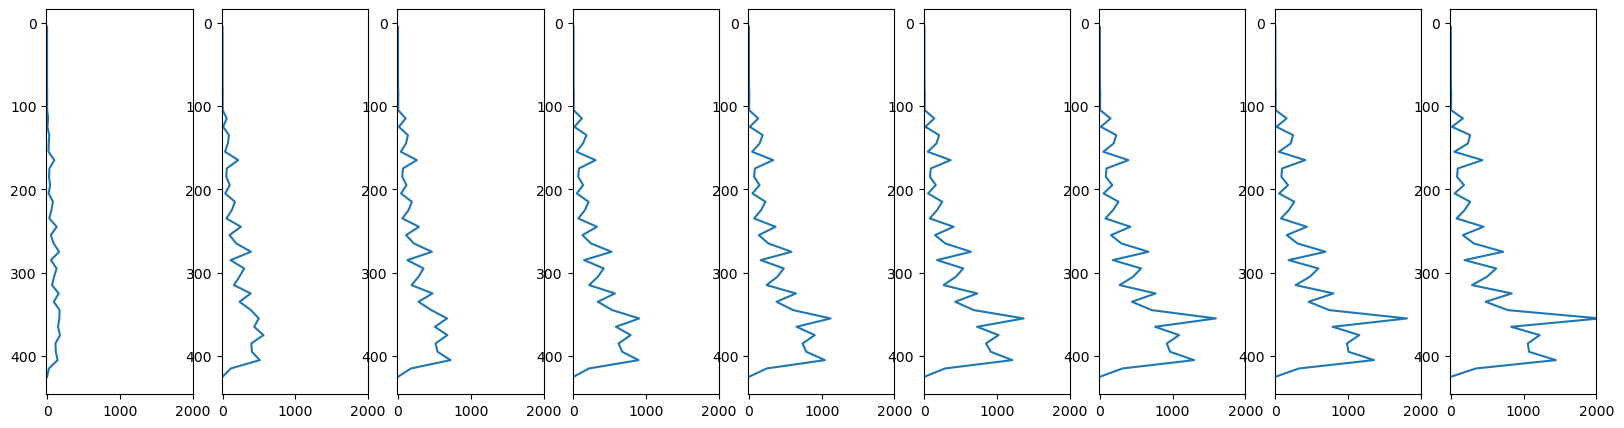

In [55]:
fig, ax = plt.subplots(1,9,figsize = (20,5))
ax[0].plot(accumulated_profiles[0].mean(), y_midpoints)
ax[1].plot(accumulated_profiles[1].mean(), y_midpoints)
ax[2].plot(accumulated_profiles[2].mean(), y_midpoints)
ax[3].plot(accumulated_profiles[3].mean(), y_midpoints)
ax[4].plot(accumulated_profiles[4].mean(), y_midpoints)
ax[5].plot(accumulated_profiles[5].mean(), y_midpoints)
ax[6].plot(accumulated_profiles[6].mean(), y_midpoints)
ax[7].plot(accumulated_profiles[7].mean(), y_midpoints)
ax[8].plot(accumulated_profiles[8].mean(), y_midpoints)
#
for axis in ax:
    axis.invert_yaxis()
    axis.set_xlim(-10, 2000)

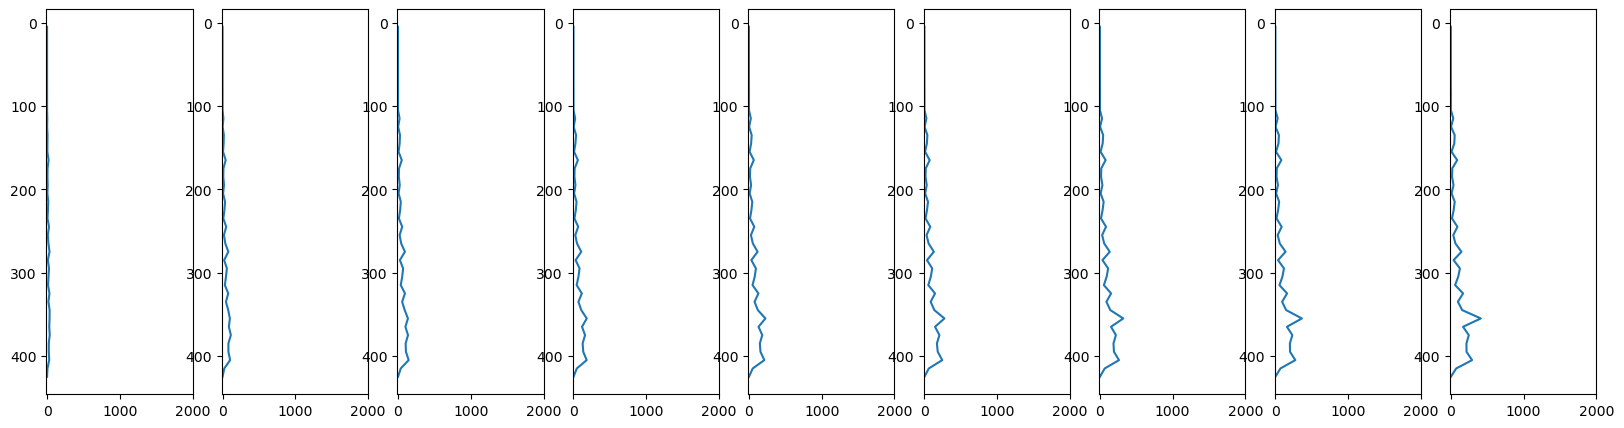

In [57]:
fig, ax = plt.subplots(1,9,figsize = (20,5))
ax[0].plot(accumulated_profiles_P[0].mean(), y_midpoints)
ax[1].plot(accumulated_profiles_P[1].mean(), y_midpoints)
ax[2].plot(accumulated_profiles_P[2].mean(), y_midpoints)
ax[3].plot(accumulated_profiles_P[3].mean(), y_midpoints)
ax[4].plot(accumulated_profiles_P[4].mean(), y_midpoints)
ax[5].plot(accumulated_profiles_P[5].mean(), y_midpoints)
ax[6].plot(accumulated_profiles_P[6].mean(), y_midpoints)
ax[7].plot(accumulated_profiles_P[7].mean(), y_midpoints)
ax[8].plot(accumulated_profiles_P[8].mean(), y_midpoints)
#
for axis in ax:
    axis.invert_yaxis()
    axis.set_xlim(-10, 2000)

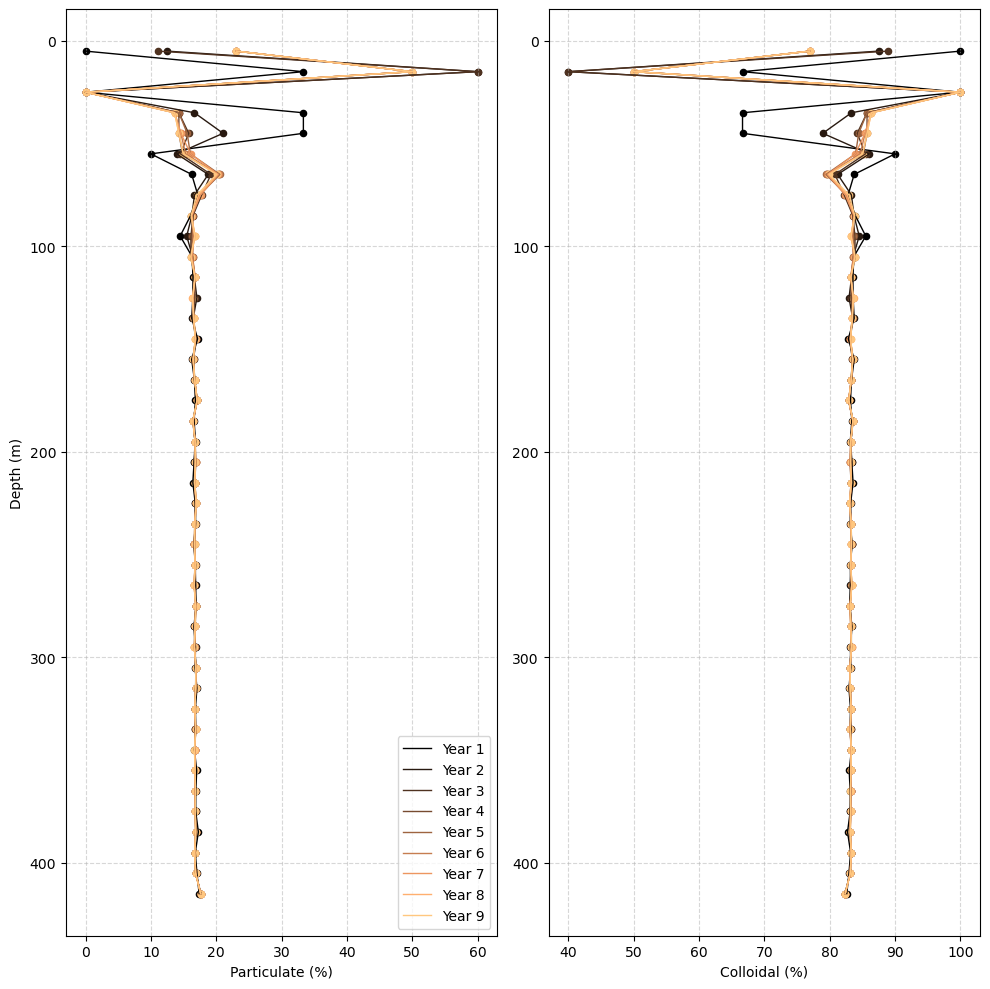

In [89]:
import matplotlib.cm as cm

# 1. Set up the figure and axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 10))

# 2. Get the number of years and set up a colormap
num_years = len(accumulated_profiles)
# np.linspace(0, 1, num_years) creates evenly spaced values for the colormap
colors = cm.copper(np.linspace(0, 1, num_years))

# 3. Loop through every year in your accumulated lists
for i in range(num_years):
    
    # --- Math calculations for the current year (i) ---
    ts_total = accumulated_profiles[i] + accumulated_profiles_P[i]
    ts_pct_C = (accumulated_profiles[i] / ts_total) * 100
    ts_pct_P = (accumulated_profiles_P[i] / ts_total) * 100
    
    mean_C = ts_pct_C.mean()
    mean_P = ts_pct_P.mean()
    
    # --- Plotting Particulate on ax1 ---
    ax1.scatter(mean_P, y_midpoints, marker='o', s=20, color=colors[i])
    # Add a label so the legend knows which line is which year
    ax1.plot(mean_P, y_midpoints, color=colors[i], linewidth=1, label=f'Year {i+1}')
    
    # --- Plotting Colloidal on ax2 ---
    ax2.scatter(mean_C, y_midpoints, marker='o', s=20, color=colors[i])
    ax2.plot(mean_C, y_midpoints, color=colors[i], linewidth=1) 
    # (Leaving the label off ax2 so we only generate one master legend)

# --- Formatting the final figure ---
ax1.set_xlabel('Particulate (%)')
ax1.set_ylabel('Depth (m)')
ax1.grid(True, linestyle='--', alpha=0.5)
# Add the legend to the first plot
ax1.legend(loc='lower right')

ax2.set_xlabel('Colloidal (%)')
ax2.grid(True, linestyle='--', alpha=0.5)

for ax in [ax1, ax2]:
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

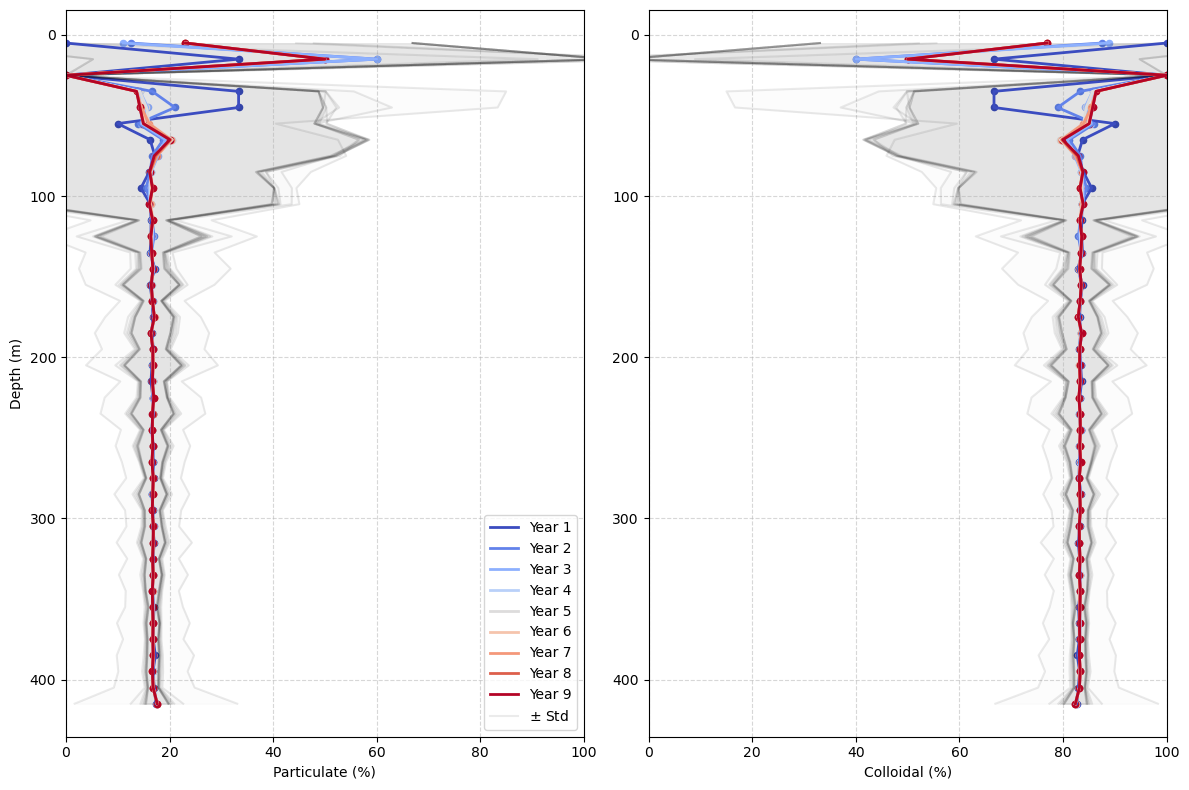

In [118]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

num_years = len(accumulated_profiles)
colors = cm.coolwarm(np.linspace(0, 1, num_years))

for i in range(num_years):
    
    ts_total = accumulated_profiles[i] + accumulated_profiles_P[i]
    ts_pct_C = (accumulated_profiles[i] / ts_total) * 100
    ts_pct_P = (accumulated_profiles_P[i] / ts_total) * 100
    
    mean_C = ts_pct_C.mean()
    mean_P = ts_pct_P.mean()
    std_C = ts_pct_C.std()
    std_P = ts_pct_P.std()
    

    ax1.fill_betweenx(y_midpoints, mean_P - std_P, mean_P + std_P, color='k', alpha=0.01, edgecolor='k')
    ax1.plot(mean_P - std_P, y_midpoints,  color='k', alpha=0.08)
    ax1.plot(mean_P + std_P, y_midpoints,  color='k', alpha=0.08)

    ax2.fill_betweenx(y_midpoints, mean_C - std_C, mean_C + std_C, color='k', alpha=0.01, edgecolor='k')
    ax2.plot(mean_C - std_C, y_midpoints,  color='k', alpha=0.08)
    ax2.plot(mean_C + std_C, y_midpoints,  color='k', alpha=0.08)
    
    ax1.scatter(mean_P, y_midpoints, marker='o', s=20, color=colors[i])
    ax1.plot(mean_P, y_midpoints, color=colors[i], linewidth=2, label=f'Year {i+1}')
    
    ax2.scatter(mean_C, y_midpoints, marker='o', s=20, color=colors[i])
    ax2.plot(mean_C, y_midpoints, color=colors[i], linewidth=2)

ax1.set_xlabel('Particulate (%)')
ax1.set_ylabel('Depth (m)')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.plot(mean_P + std_P, y_midpoints,  color='k', alpha=0.08, label = f'$\pm$ Std')
ax1.legend(loc='lower right')

ax2.set_xlabel('Colloidal (%)')
ax2.grid(True, linestyle='--', alpha=0.5)

for ax in [ax1, ax2]:
    ax.invert_yaxis()

    ax.set_xlim(0, 100) 

plt.tight_layout()
plt.show()